In [1]:
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
import pandas as pd
import numpy as np


from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.ligsaf_settings import feed_parameters, prices, price_data
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.rcf_oil_purification import create_rcf_oil_purification_system
from lignin_saf.systems.monomer_purification import create_monomer_purification_system
from lignin_saf.systems.hdo import create_hdo_system
from lignin_saf.systems.cellulosic_ethanol_no_preatreatment import create_cellulosic_ethanol_system
from atj_saf.atj_bst.etj_no_facilities import create_etj_system_no_facilities
from lignin_saf.cellulosic_tea import create_cellulosic_ethanol_tea






chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 541.7   # 2016 USD basis

# Poplar group must be defined before creating any stream that references it
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

# ── Area 200: RCF process ──────────────────────────────────────────────────
rcf_system = create_rcf_system(ins=poplar_in)
rcf_system.simulate()

# ── Area 300: Purification ─────────────────────────────────────────────────
rcf_oil_purification_sys = create_rcf_oil_purification_system(ins=F.RCF_CRUDE_OUT)
monomer_purification_sys = create_monomer_purification_system(ins=F.PURE_OIL_OUT)
rcf_oil_purification_sys.simulate()
monomer_purification_sys.simulate()

# ── Area 400: Hydrodeoxygenation ───────────────────────────────────────────
hdo_system = create_hdo_system(ins=F.MON_MONOMERS_OUT)
hdo_system.simulate()

etoh_system = create_cellulosic_ethanol_system(ins=F.Carbohydrate_Pulp, add_denaturant=False)
etoh_system.simulate()

# No pretreatment_wastewater — only S401 stillage filtrate goes to WWT.
etoh_ww     = [F.unit.S401.outs[1]]
etoh_solids = [F.unit.S401.outs[0]]

# Removing the NH3 fraction of the ethanol output - in the future CBP will remove this anyways, so I've just modelled it as a splitter
nh3_splitter = bst.units.Splitter(ins = F.T703.outs[0], split = {'NH3':1.0} )
nh3_splitter.simulate()

# Ethanol to Jet system
etj_system = create_etj_system_no_facilities(ins = nh3_splitter.outs[1])
etj_system.simulate()


WWT = bst.create_conventional_wastewater_treatment_system('WWT', ins=[F.WW_10, F.WastePulp, F.RCF_WW_OUTS, F.WW_11, F.WW_12, F.HDO_WW, F.HDO_wash_water, F.ETJ_WW_OUTS] + etoh_ww)

for unit in WWT.units:
    if hasattr(unit, 'strict_moisture_content'):
        unit.strict_moisture_content = False

F.unit.PWC.ins[0] = WWT.outs[2]

solids_to_BT = bst.Mixer('MIX_BT_solids', ins=[WWT.outs[1]] + etoh_solids)


BT = bst.facilities.BoilerTurbogenerator('BT', fuel_price=prices['CH4'])


gas_mixer= bst.Mixer('MIX_BT_gas', ins=(WWT.outs[0], F.RCF_PSAWASTE_OUTS, F.HDO_purge_gases, F.ETJ_PSAWASTE_OUTS))

BT.ins[0] = solids_to_BT.outs[0]  # Connecting sludge to BT solids feed
BT.ins[1] = gas_mixer.outs[0]   # Connecting biogas from WW treatment and PSA waste gases from RCF

combined_saf = bst.units.Mixer(ins = (F.ETJ_SAF_OUT, F.HDO_CYCLOALKANES_OUT), outs = 'TOTAL_SAF', rigorous = True)


rcf_pure_mon_hdo_etoh_etj_system = bst.System(
    'RCF+HDO+Cellulosic_ETJ',
    path=(rcf_system, rcf_oil_purification_sys, monomer_purification_sys, hdo_system, etoh_system, etj_system, combined_saf, WWT),
    facilities=[solids_to_BT, gas_mixer, BT],
)

rcf_pure_mon_hdo_etoh_etj_system.simulate()


F.Hydrogen_In.price = price_data['hydrogen']   # 8.46 USD/kg
F.RN.price = price_data['renewable_naphtha']   # 0.71 USD/kg
F.RD.price = price_data['renewable_diesel']    # 1.888 USD/kg

integrated_tea = create_cellulosic_ethanol_tea(rcf_pure_mon_hdo_etoh_etj_system)
mjsp = round(((integrated_tea.solve_price(F.TOTAL_SAF)*F.TOTAL_SAF.rho)/264.172),2)

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Hydrogen has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.34e+03 hp), head (3.2e+03 ft), kinematic viscosity (5.83e-07 m2/s), and NPSH (4.18 ft); assuming centrigugal pump
  warn(f'{repr(self)} no pump type available at current power '
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:411: CostWarning: <SolvolysisReactor: RCF_RXR1> Vertical vessel length (58.75 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:1241: CostWarning: <IsentropicCompressor: RCF_COMP1> power (1.48

Font: Arial


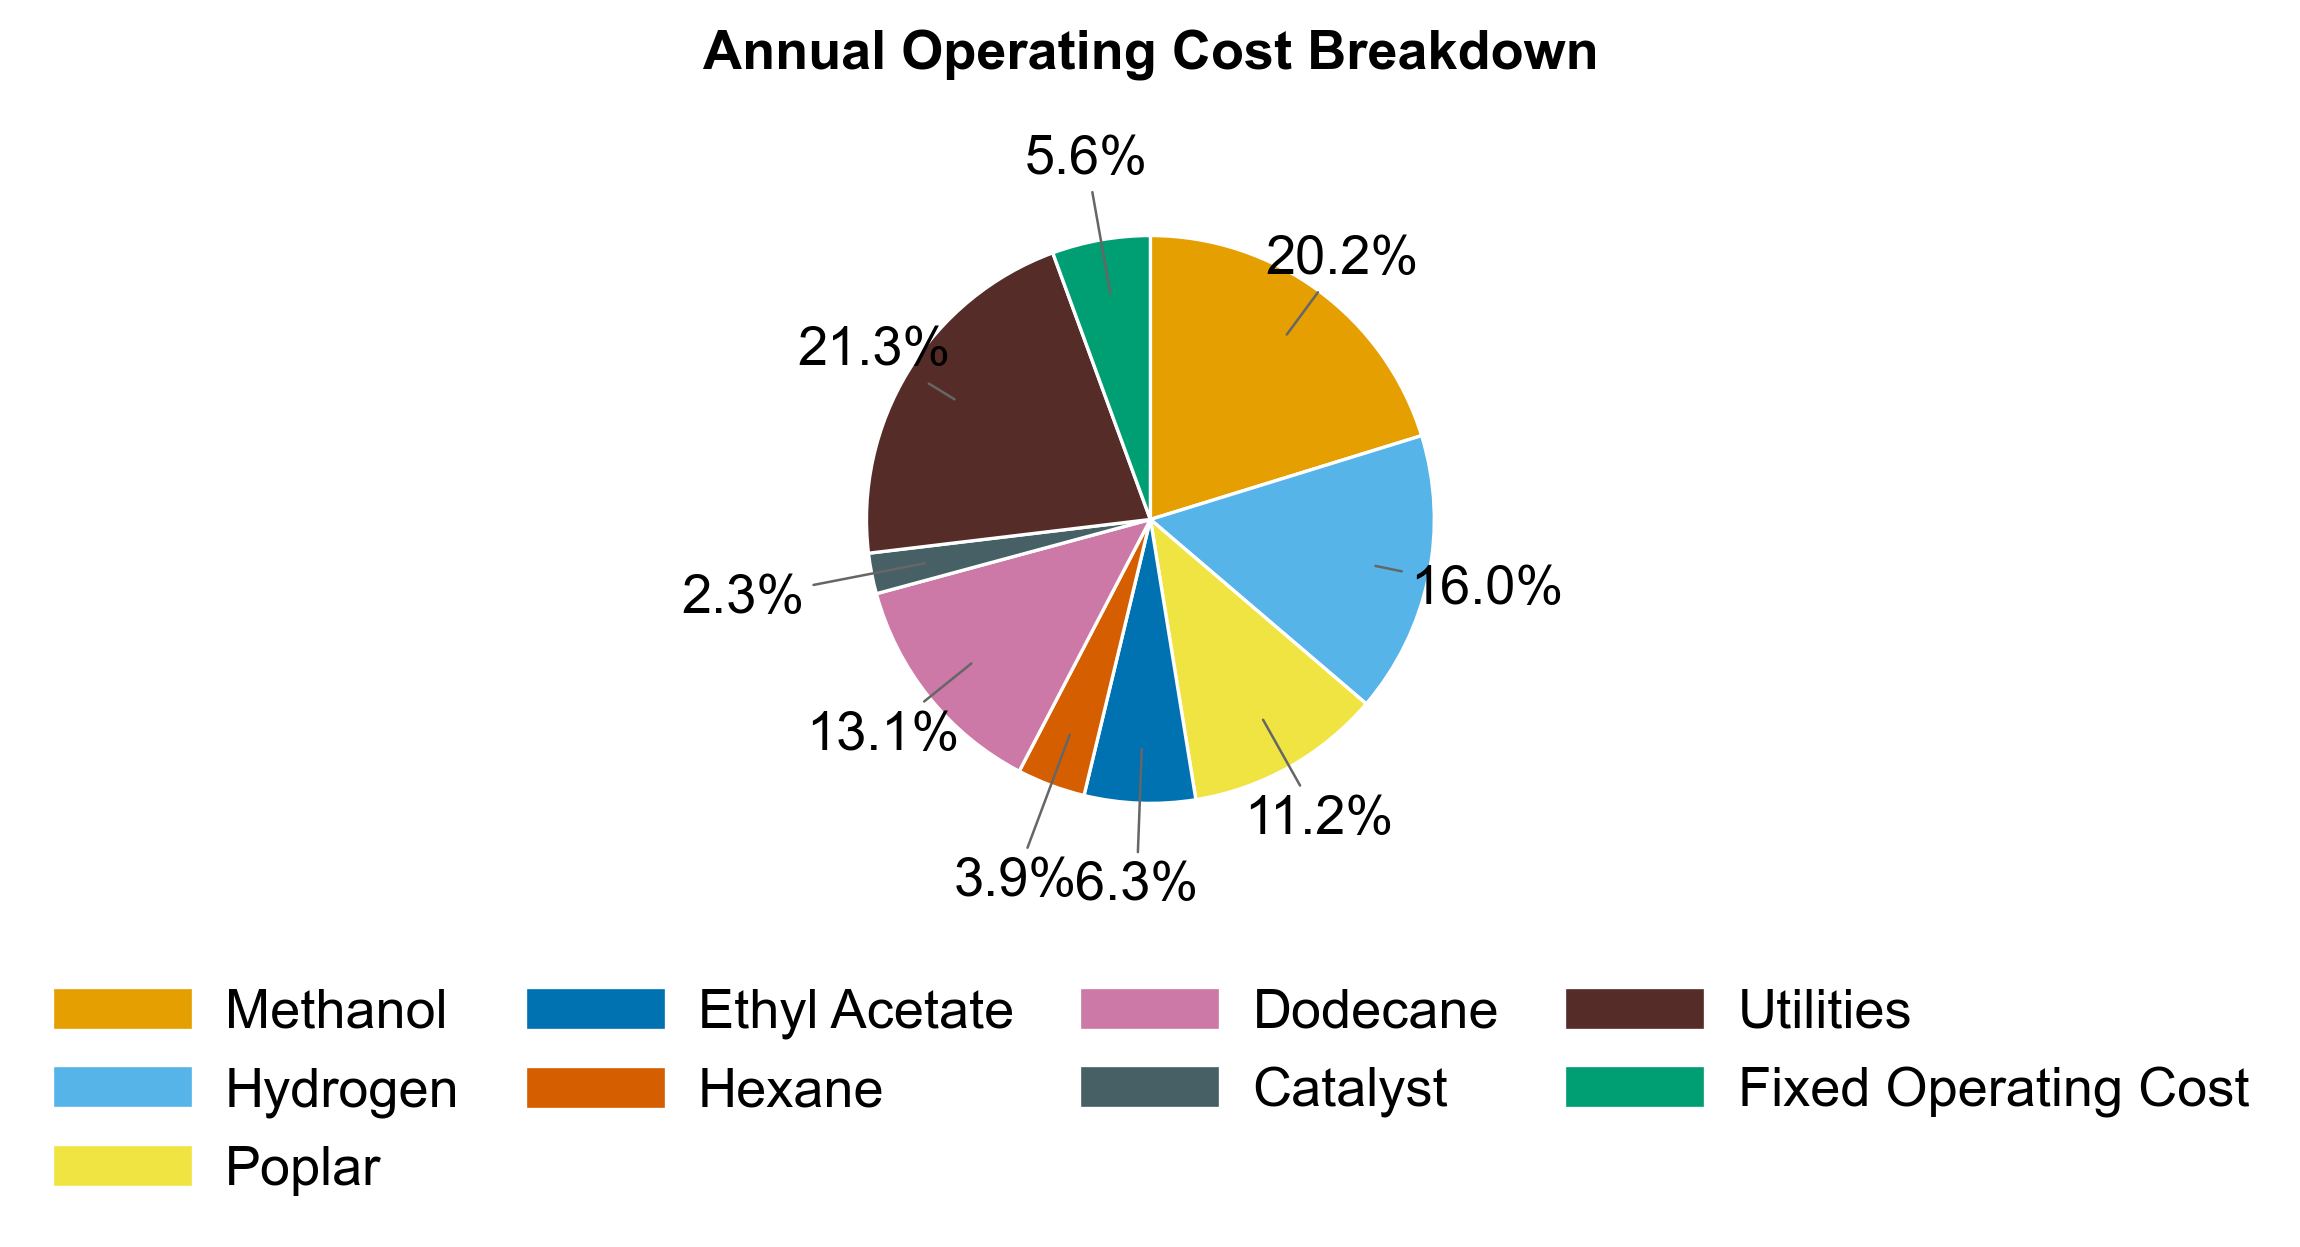

In [2]:
# Operating costs plot
methanol_price = F.RCF_MEOH_IN.F_mass * prices['Methanol'] * integrated_tea.operating_hours
hydrogen_price = (F.RCF_H2_IN.F_mass + F.HDO_H2_IN.F_mass + F.Hydrogen_In.F_mass) * prices['Hydrogen'] * integrated_tea.operating_hours
poplar_price = F.Poplar_In.F_mass * prices['Feedstock'] * integrated_tea.operating_hours
ethyl_acetate_price = F.EthylAcetate_in.F_mass * prices['EthylAcetate'] * integrated_tea.operating_hours
hexane_price = F.Hexane_In.F_mass * prices['Hexane'] * integrated_tea.operating_hours
dodecane_price = F.HDO_DODECANE_IN.F_mass * prices['Dodecane'] * integrated_tea.operating_hours
# NOTE: ETJ catalyst replacement streams (Dehyd_cat_replacement, Olig_cat_replacement,
# Hydgn_cat_replacement) have no price set, so they are NOT in the TEA's material_cost.
# Including them here makes the chart total exceed the TEA's operating cost by that amount.
catalyst = (
    F.RCF_CAT_IN.F_mass * prices['NiC_catalyst']
    + F.HDO_CAT_IN.F_mass * prices['HDO_Cat']
    + F.Dehyd_cat_replacement.F_mass * price_data['dehydration_catalyst']
    + F.Olig_cat_replacement.F_mass * price_data['oligomerization_catalyst']
    + F.Hydgn_cat_replacement.F_mass * price_data['hydrogenation_catalyst']
) * integrated_tea.operating_hours
material_arrz = np.array([methanol_price, hydrogen_price, poplar_price,
                            ethyl_acetate_price, hexane_price, dodecane_price, catalyst])

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Font ──────────────────────────────────────────────────────────────────────
font_pref = ["Arial"]
available = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
chosen = next((f for f in font_pref if f in available), "DejaVu Sans")
print(f"Font: {chosen}")

plt.rcParams.update({
    "font.family": chosen,
    "mathtext.fontset": "custom",
    "mathtext.rm": chosen,
    "mathtext.it": chosen,
    "mathtext.bf": chosen,
})

plt.rcParams['svg.fonttype'] = 'none'

oi_colors = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#476066",  # dark teal
    "#562C29",  # dark brown
    "#009E73",  # bluish green
]

categories = [
    "Methanol",
    "Hydrogen",
    "Poplar",
    "Ethyl Acetate",
    "Hexane",
    "Dodecane",
    "Catalyst",
    "Utilities",
    "Fixed Operating Cost",
]



values = [
    methanol_price,
    hydrogen_price,
    poplar_price,
    ethyl_acetate_price,
    hexane_price,
    dodecane_price,
    catalyst,
    integrated_tea.utility_cost,
    integrated_tea.FOC,
]

# ── Figure ────────────────────────────────────────────────────────────────────
DPI      = 300
fig_w_px = 1500
fig_h_px = 1260
fig_w_in = fig_w_px / DPI
fig_h_in = fig_h_px / DPI

FS_TITLE  = 13
FS_TOTAL  = 13
FS_PCT    = 13
FS_LEGEND = 13

fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in))

# ── draw_pie ──────────────────────────────────────────────────────────────────
def draw_pie(ax, vals, title):
    total    = sum(vals)
    total_MM = total / 1e6
    fracs    = [v / total for v in vals]

    wedges, _ = ax.pie(
        vals,
        colors=oi_colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(linewidth=0.8, edgecolor="white"),
    )

    label_data = []
    for i, (wedge, frac) in enumerate(zip(wedges, fracs)):
        pct   = frac * 100
        theta = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        if pct >= 20:   r_out = 1.14
        elif pct >= 10: r_out = 1.21
        elif pct >= 5:  r_out = 1.29
        else:           r_out = 1.38
        label_data.append(dict(theta=theta, pct=pct, r_out=r_out, r_in=0.78, idx=i))

    small_indices = [d["idx"] for d in label_data if d["pct"] < 5]
    for j, idx in enumerate(small_indices):
        label_data[idx]["r_out"] = 1.36 if j % 2 == 0 else 1.46

    for d in label_data:
        theta, r_in, r_out, pct = d["theta"], d["r_in"], d["r_out"], d["pct"]
        ax.annotate(
            f"{pct:.1f}%",
            xy=(r_in  * np.cos(theta), r_in  * np.sin(theta)),
            xytext=(r_out * np.cos(theta), r_out * np.sin(theta)),
            fontsize=FS_PCT,
            ha="center", va="center",
            arrowprops=dict(
                arrowstyle="-", color="#666666", lw=0.6,
                shrinkA=0, shrinkB=2,
            ),
        )

    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=6)
    # ax.text(0, -1.72,
    #         r"Total: " + f"{total_MM:.1f}" + r" MM $",
    #         ha="center", va="top", fontsize=FS_TOTAL,
    #         color="#222222", fontweight="bold", style="normal")

    ax.set_xlim(-1.65, 1.65)
    ax.set_ylim(-1.95, 1.50)

draw_pie(ax, values, "Annual Operating Cost Breakdown")

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(facecolor=c, edgecolor="white", linewidth=0.8, label=lbl)
    for c, lbl in zip(oi_colors, categories)
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    fontsize=FS_LEGEND,
    frameon=False,
    columnspacing=1.2,
    handlelength=2.6,
    handleheight=0.85,
    handletextpad=0.6,
    bbox_to_anchor=(0.5, 0.0),
)

fig.tight_layout(rect=[0, 0.10, 1, 1])

#fig.savefig("operating_breakdown_2.svg", format="svg", bbox_inches="tight")
#print("Done.")


In [3]:
(712/1000) * 1.35 * (226.6/285.6) 

0.7626327731092437

In [4]:
fig.show()

C:\Users\hwadg\AppData\Local\Temp\ipykernel_30976\89474557.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
